In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import numpy as np
import os
df = pd.read_csv('/Users/masonwang/Documents/Projects/Time Series Analysis/NZD-USD-Exchange-Rate-Forecaster/data/raw/nzd_usd.csv')
#DEXUSNZ is quoted as U.S. dollars per 1 New Zealand dollar. In this project, I use DEXUSNZ directly as the target exchange-rate series.

## 1. basic structure
This section checks the shape, column names, and first few rows of the raw FRED dataset.

In [2]:
df.shape, df.columns

((2610, 2), Index(['observation_date', 'DEXUSNZ'], dtype='str'))

In [3]:
df.head()

,observation_date,DEXUSNZ
0,2016-06-06,0.6931
1,2016-06-07,0.6981
2,2016-06-08,0.7024
3,2016-06-09,0.7133
4,2016-06-10,0.7069


In [4]:
df.tail()

,observation_date,DEXUSNZ
2605,2026-06-01,0.5931
2606,2026-06-02,0.5933
2607,2026-06-03,0.5871
2608,2026-06-04,0.5879
2609,2026-06-05,0.5809


The dataset loaded successfully. It contains one date column, `observation_date`, and one exchange-rate column, `DEXUSNZ`. The first and last rows show that the data is ordered chronologically and covers multiple years of NZD/USD exchange-rate observations.

## 2. Column definitions

`observation_date` is the date of the exchange-rate observation.

`DEXUSNZ` is the FRED exchange-rate series for U.S. dollars per 1 New Zealand dollar. In this project, I use `DEXUSNZ` directly as the target exchange-rate series.

This means the project is modeling:

1 NZD = x USD

## 3. Date audit

This section checks whether the date column is stored correctly, whether the observations are ordered by time, and whether there are duplicate dates.

In [5]:
df.dtypes

observation_date        str
DEXUSNZ             float64
dtype: object

In [6]:
df['observation_date'] = pd.to_datetime(df['observation_date'], yearfirst = True, format = "%Y-%m-%d")
df.info()
        

<class 'pandas.DataFrame'>
RangeIndex: 2610 entries, 0 to 2609
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  2610 non-null   datetime64[us]
 1   DEXUSNZ           2498 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 40.9 KB


In [7]:
df['observation_date'].min(), df['observation_date'].max()

(Timestamp('2016-06-06 00:00:00'), Timestamp('2026-06-05 00:00:00'))

The dataset covers observations from 2016-06-06 to 2026-06-05.

In [8]:
df['observation_date'].is_monotonic_increasing

True

The date column was converted to a datetime type and sorted in chronological order. This is necessary because future transformations, such as calculating returns, depend on the previous observation.

In [9]:
df['observation_date'].duplicated().sum()

np.int64(0)

The dataset has no duplicate dates. After sorting, the observations are in chronological order from 2016-06-06 to 2026-06-05. This makes the dataset suitable for time-based transformations later.

## 4. Missing-value audit

This section checks how many exchange-rate observations are missing in the `DEXUSNZ` column.

In [10]:
df['DEXUSNZ'].isna().sum()

np.int64(112)

In [11]:
df['DEXUSNZ'].isna().mean() * 100

np.float64(4.291187739463601)

The `DEXUSNZ` column contains 112 missing values, which is about 4.3% of the dataset. These missing values need to be handled before calculating log returns or fitting forecasting models.

In [12]:
df[df['DEXUSNZ'].isna()].head(10)

,observation_date,DEXUSNZ
20,2016-07-04,NaN
65,2016-09-05,NaN
90,2016-10-10,NaN
114,2016-11-11,NaN
123,2016-11-24,NaN
145,2016-12-26,NaN
150,2017-01-02,NaN
160,2017-01-16,NaN
164,2017-01-20,NaN
185,2017-02-20,NaN


The first missing `DEXUSNZ` observations appear to fall on U.S. holidays or other non-publication days. This suggests that the missing values are likely calendar-related rather than data corruption.

In [13]:
df[df['DEXUSNZ'].isna()].tail(10)

,observation_date,DEXUSNZ
2369,2025-07-04,NaN
2410,2025-09-01,NaN
2440,2025-10-13,NaN
2461,2025-11-11,NaN
2473,2025-11-27,NaN
2493,2025-12-25,NaN
2498,2026-01-01,NaN
2510,2026-01-19,NaN
2530,2026-02-16,NaN
2600,2026-05-25,NaN


The missing `DEXUSNZ` values appear to occur mostly on U.S. holidays or non-publication days. They do not appear to be random data corruption. For the first version of this project, I will remove missing exchange-rate observations before calculating log returns.

## 5. Basic value audit

This section checks whether the `DEXUSNZ` exchange-rate values have a plausible range and whether there are obvious impossible values such as zero or negative exchange rates.

In [14]:
df['DEXUSNZ'].describe()

count    2498.000000
mean        0.651866
std         0.050818
min         0.553600
25%         0.606300
50%         0.653850
75%         0.697975
max         0.750600
Name: DEXUSNZ, dtype: float64

The `DEXUSNZ` values range from approximately 0.55 to 0.75, which is plausible for an NZD/USD exchange-rate series. There are no obvious impossible values such as zero, negative rates, or extreme outliers.

## 6. Visual sanity check

This section plots the raw `DEXUSNZ` series over time to check whether the exchange-rate movement looks continuous and plausible.

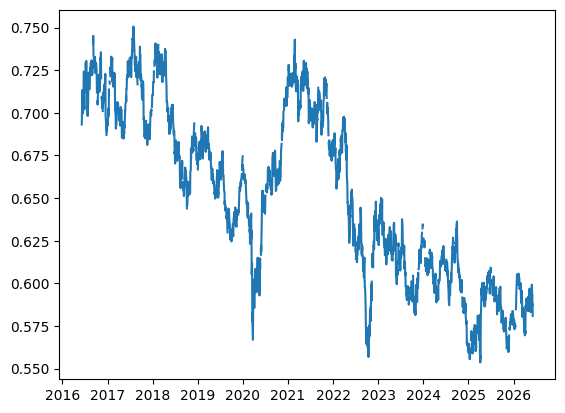

In [15]:
plt.plot(df.observation_date,df.DEXUSNZ)

The raw `DEXUSNZ` series appears visually plausible. The exchange rate moves within a reasonable range, with no obvious impossible jumps or corrupted sections. The series shows persistent movement over time and some sharper periods of change, which is typical of financial exchange-rate data.

## 7. Missing-value handling decision

The missing `DEXUSNZ` values appear to occur mostly on holidays or non-publication days. For this first version, I will remove rows where `DEXUSNZ` is missing before calculating log exchange rates and returns. This avoids introducing assumptions through interpolation or forward-filling.

In [16]:
df_clean = df.dropna(how='any',axis=0)
df_clean['observation_date'] = pd.to_datetime(df['observation_date'], yearfirst=True, format='%Y-%m-%d')
df_clean.sort_values('observation_date',axis=0,ascending=True,inplace=True)
df_clean.reset_index(inplace=True,drop=True)
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2498 entries, 0 to 2497
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  2498 non-null   datetime64[us]
 1   DEXUSNZ           2498 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 39.2 KB


Rows with missing `DEXUSNZ` values were removed, leaving 2,498 usable observations. The cleaned dataset keeps `observation_date` as a datetime column and `DEXUSNZ` as a numeric exchange-rate column.

## 8. Log exchange rate

This section creates a log-transformed version of the NZD/USD exchange rate. Log transformations are commonly used in financial time series because changes in logs can be interpreted approximately as percentage changes.

In [17]:
df_clean['log_nzd_usd'] = np.log(df_clean['DEXUSNZ'])
df_clean.info()
df_clean.head()

<class 'pandas.DataFrame'>
RangeIndex: 2498 entries, 0 to 2497
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  2498 non-null   datetime64[us]
 1   DEXUSNZ           2498 non-null   float64       
 2   log_nzd_usd       2498 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 58.7 KB


,observation_date,DEXUSNZ,log_nzd_usd
0,2016-06-06,0.6931,-0.366581
1,2016-06-07,0.6981,-0.359393
2,2016-06-08,0.7024,-0.353252
3,2016-06-09,0.7133,-0.337853
4,2016-06-10,0.7069,-0.346866


The `log_nzd_usd` column was created by taking the natural log of `DEXUSNZ`. The log values are negative because the NZD/USD exchange rate is below 1 throughout this sample, which is expected.

## 9. Log returns

This section creates daily log returns for the NZD/USD exchange rate. A log return measures the change in the log exchange rate from one observation to the next.

In [18]:
df_clean['nzd_usd_return'] = df_clean['log_nzd_usd'] - df_clean['log_nzd_usd'].shift(periods=1,axis=0)
df_clean.head()

,observation_date,DEXUSNZ,log_nzd_usd,nzd_usd_return
0,2016-06-06,0.6931,-0.366581,NaN
1,2016-06-07,0.6981,-0.359393,0.007188
2,2016-06-08,0.7024,-0.353252,0.006141
3,2016-06-09,0.7133,-0.337853,0.015399
4,2016-06-10,0.7069,-0.346866,-0.009013


The first log return is missing because there is no previous observation to compare against. Subsequent values represent the change in the log NZD/USD exchange rate from the previous available observation.

## 10. Summary statistics

This section checks basic summary statistics for the original exchange-rate series, the log exchange rate, and the log return series.

In [19]:
df_clean['DEXUSNZ'].describe()

count    2498.000000
mean        0.651866
std         0.050818
min         0.553600
25%         0.606300
50%         0.653850
75%         0.697975
max         0.750600
Name: DEXUSNZ, dtype: float64

In [20]:
df_clean['log_nzd_usd'].describe()

count    2498.000000
mean       -0.430970
std         0.078272
min        -0.591313
25%        -0.500380
50%        -0.424877
75%        -0.359572
max        -0.286882
Name: log_nzd_usd, dtype: float64

In [21]:
df_clean['nzd_usd_return'].describe()

count    2497.000000
mean       -0.000071
std         0.006416
min        -0.038925
25%        -0.003888
50%         0.000000
75%         0.003728
max         0.028540
Name: nzd_usd_return, dtype: float64

The average `DEXUSNZ` value is approximately 0.652, meaning 1 NZD was worth about 0.65 USD on average during the sample period. The mean log return is close to zero, which is typical for daily financial return series. The return series has some larger positive and negative moves, but the range appears plausible for exchange-rate data.

## 11. Cleaned NZD/USD exchange-rate plot

This section plots the cleaned `DEXUSNZ` series after removing missing exchange-rate observations.

Text(0, 0.5, 'NZD to USD Exchange Rate')

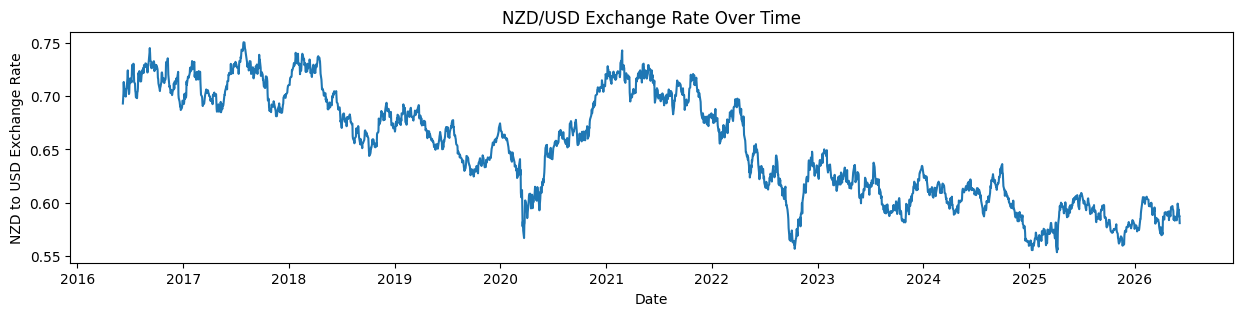

In [22]:
plt.rcParams['figure.figsize'] = (15,3)
plt.plot(df_clean.observation_date,df_clean.DEXUSNZ)
plt.title('NZD/USD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('NZD to USD Exchange Rate')


The cleaned `DEXUSNZ` series appears continuous and plausible after removing missing observations. The exchange rate stays roughly between 0.55 and 0.75 U.S. dollars per 1 NZD. The series shows persistent movement over time, with a broad decline from the 2016–2018 range toward lower levels in 2022–2025, indicating periods of NZD weakness against the USD.

## 12. Log NZD/USD exchange-rate plot

This section plots the log-transformed NZD/USD exchange rate. The log series preserves the same broad movement as the original exchange-rate level but is useful for calculating log returns.

Text(0.5, 0, 'Date')

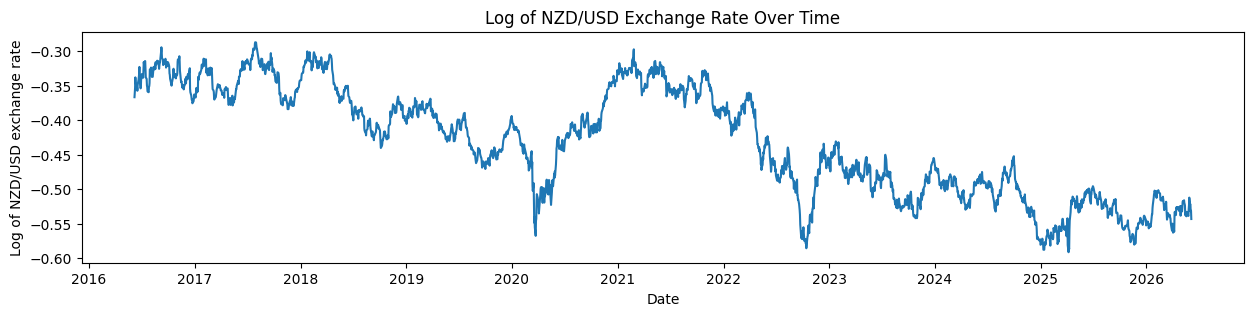

In [23]:
plt.plot(df_clean.observation_date,df_clean.log_nzd_usd)
plt.title('Log of NZD/USD Exchange Rate Over Time')
plt.ylabel('Log of NZD/USD exchange rate')
plt.xlabel('Date')

The log-transformed NZD/USD series has a similar shape to the original exchange-rate series. The values are negative because the NZD/USD exchange rate is below 1 throughout the sample. This transformed series is useful for calculating log returns.

## 13. NZD/USD log return plot

This section plots the daily log returns of the NZD/USD exchange rate. Returns show the day-to-day change in the exchange rate and are usually more useful for forecasting analysis than the raw exchange-rate level.

Text(0.5, 0, 'Date')

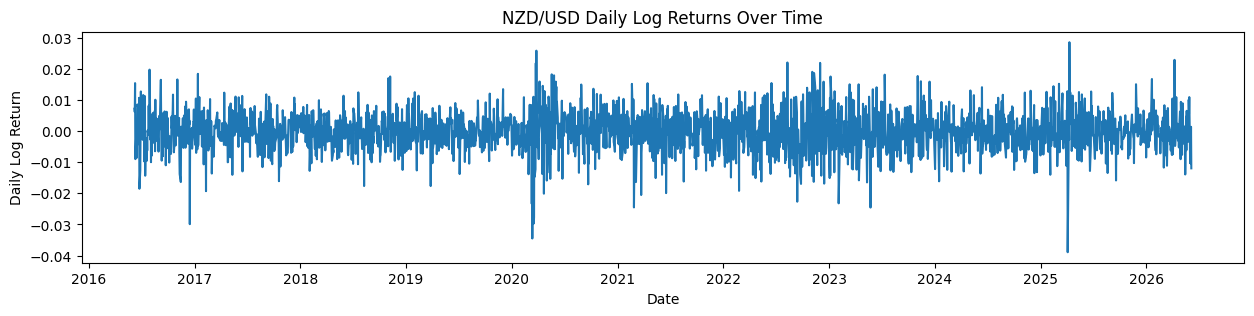

In [24]:
plt.plot(df_clean.observation_date,df_clean.nzd_usd_return)
plt.title('NZD/USD Daily Log Returns Over Time')
plt.ylabel('Daily Log Return')
plt.xlabel('Date')

The NZD/USD daily log returns fluctuate around zero, unlike the exchange-rate level series, which moves persistently over time. Most daily returns are small, but there are occasional large positive and negative spikes. Some periods appear more volatile than others, suggesting possible volatility clustering.

The return series appears much noisier than the exchange-rate level, which suggests that predicting short-term exchange-rate changes may be difficult.

## 14. Initial findings

This section summarizes the main findings from the initial data audit and transformation process.

The raw FRED dataset contains daily observations of `DEXUSNZ`, which measures U.S. dollars per 1 New Zealand dollar. After removing missing exchange-rate observations, the cleaned dataset contains 2,498 usable observations from 2016-06-06 to 2026-06-05.

The `DEXUSNZ` values range from approximately 0.55 to 0.75, which is plausible for an NZD/USD exchange-rate series. Missing values appear to occur mostly on holidays or non-publication days rather than from obvious data corruption.

The exchange-rate level is persistent and shows broad movements over time. The log-transformed series preserves this same broad shape. The daily log return series fluctuates around zero, contains occasional large spikes, and appears much noisier than the level series. This suggests that short-term exchange-rate forecasting may be difficult and should be evaluated against simple baselines later.

## 15. Save cleaned dataset

This section saves the cleaned and transformed dataset as a separate processed CSV file. The original raw FRED file is left unchanged.

In [25]:
df_clean.to_csv('/Users/masonwang/Documents/Projects/Time Series Analysis/NZD-USD-Exchange-Rate-Forecaster/data/processed/cleaned_nzd_usd.csv',index=False)

The cleaned dataset was saved as a separate processed CSV file. The saved file contains the date, original NZD/USD exchange rate, log exchange rate, and log return columns, while leaving the raw FRED file unchanged.